# Logistic Regression using Scikit-Learn.

---

In [1]:
import time

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

In [2]:
data = pd.read_csv('employee_attrition_preprocessed.csv')

## Train-Test-Split:

In [3]:
X = data.drop(columns=['Attrition'])
y = data['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

## Building Model:

In [4]:
param = {'C' : [0.01, 0.1, 1, 10, 100],
        'class_weight' : [None, 'balanced']}

grid = GridSearchCV(
    estimator=LogisticRegression(),
    param_grid=param,
    scoring='recall',
    n_jobs=-1,
    cv=5
)

grid.fit(X_train, y_train)

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the 

In [5]:
print(f"Best parameters: {grid.best_params_}")
print(f"Best Score: {grid.best_score_ * 100 :.2f}%")

Best parameters: {'C': 10, 'class_weight': 'balanced'}
Best Score: 76.92%


In [6]:
Lr = LogisticRegression(C=10, class_weight='balanced', max_iter=1000)

start_time = time.time()
Lr.fit(X_train, y_train)
end_time = time.time() - start_time

print("Model Trained Successfully!")
print(f"Time Taken for Training: {end_time:.2f}s")

Model Trained Successfully!
Time Taken for Training: 0.38s


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Results:

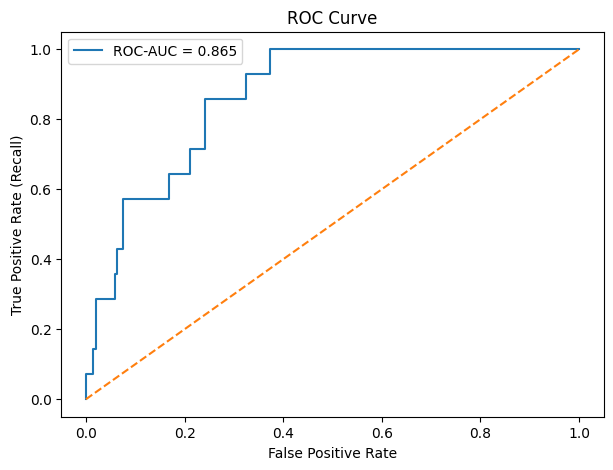

In [7]:
y_prob = Lr.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [8]:
for threshold in thresholds:
    
    y_pred = (y_prob >= threshold).astype(int)

    print(
        f"Threshold: {threshold:.3f} | "
        f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.3f} | "
        f"Precision: {precision_score(y_test, y_pred) * 100:.3f} | "
        f"Recall: {recall_score(y_test, y_pred) * 100 :.3f} | "
        f"F1: {f1_score(y_test, y_pred) * 100 :.3f}"
    )

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Threshold: inf | Accuracy: 95.395 | Precision: 0.000 | Recall: 0.000 | F1: 0.000
Threshold: 0.981 | Accuracy: 95.724 | Precision: 100.000 | Recall: 7.143 | F1: 13.333
Threshold: 0.918 | Accuracy: 94.408 | Precision: 20.000 | Recall: 7.143 | F1: 10.526
Threshold: 0.895 | Accuracy: 94.737 | Precision: 33.333 | Recall: 14.286 | F1: 20.000
Threshold: 0.887 | Accuracy: 94.079 | Precision: 25.000 | Recall: 14.286 | F1: 18.182
Threshold: 0.883 | Accuracy: 94.737 | Precision: 40.000 | Recall: 28.571 | F1: 33.333
Threshold: 0.848 | Accuracy: 91.118 | Precision: 19.048 | Recall: 28.571 | F1: 22.857
Threshold: 0.844 | Accuracy: 91.447 | Precision: 22.727 | Recall: 35.714 | F1: 27.778
Threshold: 0.844 | Accuracy: 91.118 | Precision: 21.739 | Recall: 35.714 | F1: 27.027
Threshold: 0.818 | Accuracy: 91.447 | Precision: 25.000 | Recall: 42.857 | F1: 31.579
Threshold: 0.802 | Accuracy: 90.132 | Precision: 21.429 | Recall: 42.857 | F1: 28.571
Threshold: 0.787 | Accuracy: 90.789 | Precision: 26.667 | Re

In [9]:
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

print(f"Accuracy: {(accuracy_score(y_test, y_pred)*100):.2f}%")

print(f"\nPrecision: {(precision_score(y_test, y_pred)*100):.2f}%")

print(f"\nRecall: {(recall_score(y_test, y_pred)*100):.2f}%")

print(f"\nF1 Score: {(f1_score(y_test, y_pred)*100):.2f}")

print("\n")
matrix = confusion_matrix(y_test, y_pred)
matrix_df = pd.DataFrame(matrix, index=['Actual Stay', 'Actual Leave'], columns=['Predicted Stay', 'Predicted Leave'])
matrix_df

Accuracy: 75.66%

Precision: 14.29%

Recall: 85.71%

F1 Score: 24.49




,Predicted Stay,Predicted Leave
Actual Stay,218,72
Actual Leave,2,12
